In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Neural Network from Scratch

## (For Regression)

Building Blocks: nuerons

input: vector $x=[x_1x_2\ldots x_n]$

output: $y = w_1x_1+w_2x_2+\ldots +w_nx_n+b$ // linear model

neural network:

$$
(\ldots((xW_1 + b_1)W_2+b_2)\ldots )W_m+b_m)
$$

Where $W_i$ is a matrix with $n$ rows and \# neurons in layer columns and $b_i$ is a bias vector.

But simplifying this yields $xW+b$, for some $W,b$, and is thus equivalent to linear regression.

We'll need to add some nonlinearity to the model to make it substanttively different:

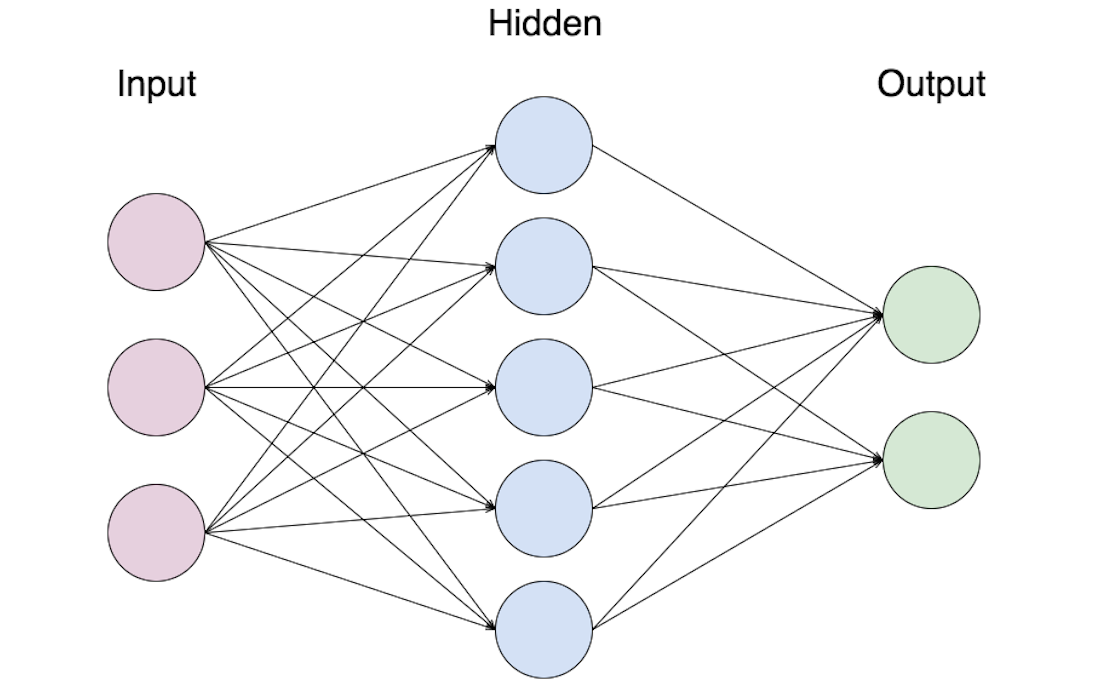

## Activation Function

$\text{input }x \to \text{neuron } y \to \text{(nonlinear activation function) }\sigma$

In the old days, $\sigma(y)=\frac{1}{1+e^{-y}}$ (the sigmoid function) was used.

We now more frequently use $\sigma(y)=\max\{0,y\}$, called the ReLU (Rectified Linear Unit) function


So, what would our updated model look like?

$$
(\ldots\sigma(\sigma(xW_1 + b_1)W_2+b_2)\ldots )W_m+b_m)
$$

We apply the sigma function on all but the final layer.

Note: sending x through the network is called a 'forward pass'
****

In [33]:
# neural network layer

class layer:
    # initialization
    def __init__(self, n_inputs,n_neurons): # self represents the instance of the class
        self.weights = 0.1*np.random.randn(n_inputs,n_neurons)# small random numbers
        self.biases = np.zeros((1,n_neurons)) #zeros
        
    def forward(self, inputs):
        
        # we need to store the outputs
        self.output = inputs.dot(self.weights)+self.biases
        
        #as well as the inputs
        self.inputs = inputs
        
    def backward(self, dinputs):
        
        self.dinputs = dinputs.dot(self.weights.T)
        self.dweights = self.inputs.T.dot(dinputs)
        self.dbiases = np.sum(dinputs, axis=0,keepdims = True)
        
        
# ReLU activation function
class ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0,inputs)
        self.inputs = inputs
        
    def backward(self,dinputs): 
        self.dinputs = dinputs.copy()
        self.dinputs[self.inputs<0]=0
        

# linear activation function

class linear:
    # f(x) = x
    def forward(self,inputs):
        self.output = inputs.flatten()
        self.inputs = inputs
        
    def backward(self, dinputs):
        self.dinputs = dinputs.copy().reshape(-1,1)
        
        
# loss function
class loss_mse:
    def forward(self,yhat,y):
        losses = (y-yhat)**2 # this is a vector but we need to compute the mean of its entries
        return losses
    
    def backward(self,yhat, y):
        self.dinputs = (-2/len(y))*(y-yhat)
        
#optimizer

class optimizer_GD:
    def __init__(self, learning_rate):
        self.learning_rate=learning_rate
        
    def update_parameters(self,layer):
        layer.weights = layer.weights - self.learning_rate*layer.dweights
        layer.biases = layer.biases - self.learning_rate*layer.dbiases
        

In [18]:
# 10 data points in R2
X = np.random.randn(10,2)

In [19]:
# create layer
layer1 = layer(n_inputs=2,n_neurons=10)
activation1 = ReLU()
layer2 = layer(n_inputs=10,n_neurons=20)
activation2 = ReLU()
layer3 = layer(n_inputs=20,n_neurons=1)
#etc

In [20]:
layer1.forward(X)

In [21]:
activation1.forward(layer1.output)

In [22]:
layer2.forward(activation1.output)

In [23]:
activation2.forward(layer2.output)

In [24]:
layer3.forward(activation2.output)

In [25]:
layer3.output

array([[-0.01466424],
       [-0.00482955],
       [-0.00802344],
       [-0.00176415],
       [-0.00249629],
       [-0.0049392 ],
       [-0.00186966],
       [-0.00243162],
       [-0.0120558 ],
       [-0.01109042]])

****
## Training a Neural Network

Given: $(x_1,y_1),\ldots,(x_n,y_m)$, for $x_i$ a vector and $y_i$ a scalar

We'll minimize:

mse: $\frac{1}{m}\sum_{i=1}^m(y_i-\hat{y}_i)^2$

We'll need to use Gradient Descent:

$\partial \text{mse} / \partial W_k[i,j], \partial \text{mse} / \partial b_k[i]$

### Backpropogation

It's just jargon for the chain rule.


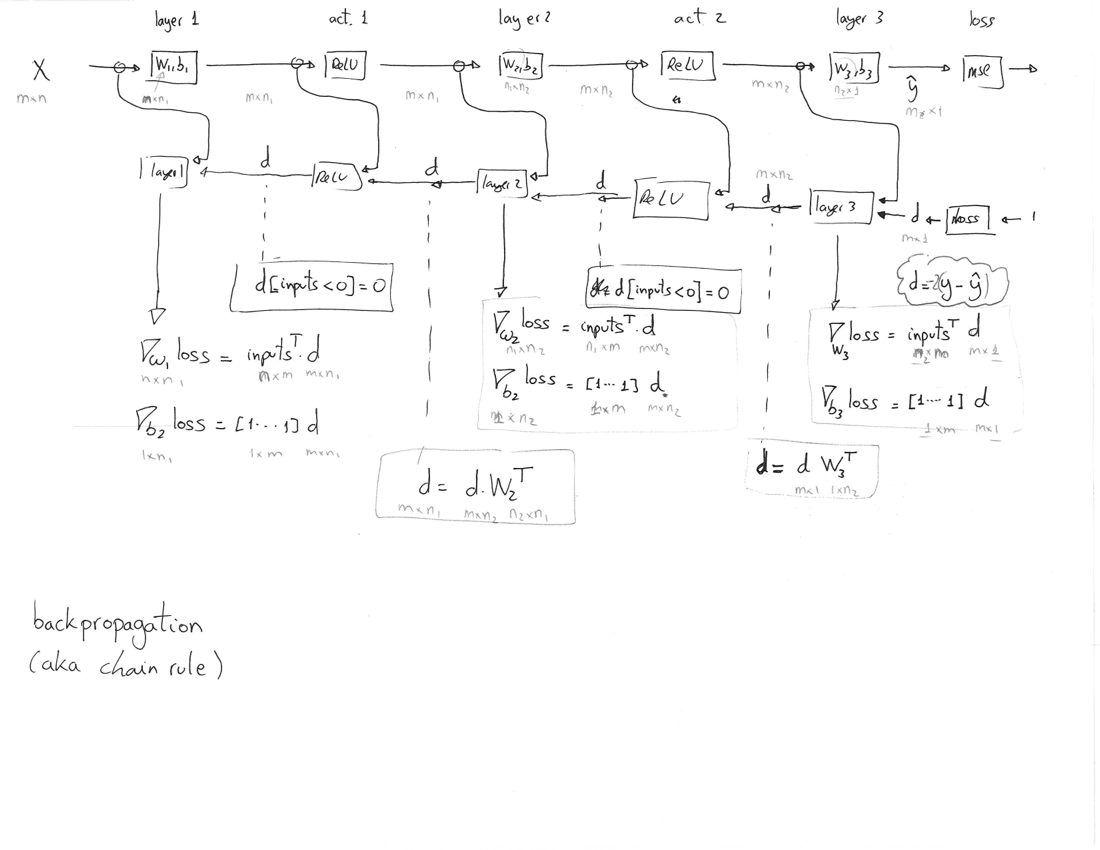

## Using our classes to run gradient descent and just do the thing I guess
****

In [37]:
# neural net initialization

# layer 1
layer1 = layer(n_inputs=2,n_neurons=64) # first layer, n_inputs = dimension of problem
activation1 = ReLU()
# layer 2
layer2 = layer(n_inputs=64,n_neurons = 64)
activation2 = ReLU()
# layer 3
layer3 = layer(n_inputs=64,n_neurons = 1)
activation3 = linear()

# loss function
loss_function = loss_mse()

#optimizer
optimizer = optimizer_GD(learning_rate=0.5)

In [27]:
# can this network learn sin(6x)cos(6y)?

m = 50
x1 = np.linspace(-1,1,m)
x2=np.linspace(-1,1,m)
X1,X2 = np.meshgrid(x1,x2)
Y = np.sin(6*X1)*np.cos(6*X2)

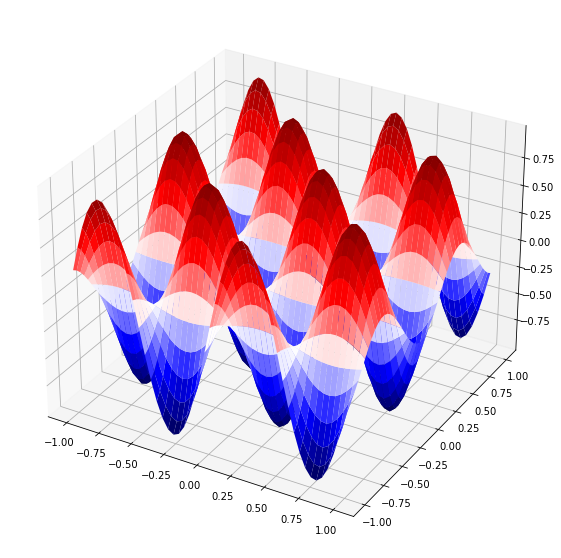

In [28]:
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(X1,X2,Y,cmap ='seismic')

In [29]:
# reshape

X = np.c_[X1.reshape(-1,1),X2.reshape(-1,1)]
y = Y.reshape(-1)

In [43]:
# gradient descent iterations

n_epochs = 2000
#loss = np.zeros(n_epochs)
for epoch in range(n_epochs):
    
    # forward pass
    layer1.forward(X)
    activation1.forward(layer1.output)
    layer2.forward(activation1.output)
    activation2.forward(layer2.output)
    layer3.forward(activation2.output)
    activation3.forward(layer3.output)
    
    losses = loss_function.forward(activation3.output,y)
    # backward pass
    loss_function.backward(activation3.output,y)
    activation3.backward(loss_function.dinputs)
    layer3.backward(activation3.dinputs)
    activation2.backward(layer3.dinputs)
    layer2.backward(activation2.dinputs)
    activation1.backward(layer2.dinputs)
    layer1.backward(layer2.dinputs)
    
    # update weights and biases
    optimizer.update_parameters(layer1)
    optimizer.update_parameters(layer2)
    optimizer.update_parameters(layer3)
    
    # print the mean squared error (every 100 epochs)
    if epoch % 100 == 0:
        print('----------------')
        print('epoch: '+str(epoch))
        print('loss: '+str(np.mean(losses)))
        print('----------------')

----------------
epoch: 0
loss: 0.07435279768226719
----------------
----------------
epoch: 100
loss: 0.07411500073242919
----------------
----------------
epoch: 200
loss: 0.07408747803586069
----------------
----------------
epoch: 300
loss: 0.07374340302668468
----------------
----------------
epoch: 400
loss: 0.07374152725951566
----------------
----------------
epoch: 500
loss: 0.0738643078553673
----------------
----------------
epoch: 600
loss: 0.07340738127634301
----------------
----------------
epoch: 700
loss: 0.07373980754068685
----------------
----------------
epoch: 800
loss: 0.07447648542878263
----------------
----------------
epoch: 900
loss: 0.07474743637829613
----------------
----------------
epoch: 1000
loss: 0.07529787871623733
----------------
----------------
epoch: 1100
loss: 0.07606614667138535
----------------
----------------
epoch: 1200
loss: 0.07685629133603726
----------------
----------------
epoch: 1300
loss: 0.07806690378875357
----------------
-----

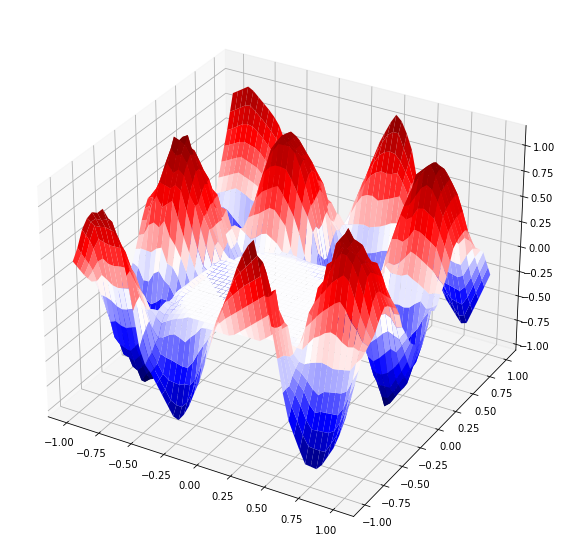

In [44]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
Yplot = activation3.output.reshape(m,m)
ax.plot_surface(X1,X2,Yplot,cmap ='seismic')